# A Simulation of the BB84 Quantum Key Distribution (QKD) Protocol


## 1. Setup & Utilities

- Import necessary packages

In [37]:
import os
import qiskit
import math
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
import pandas as pd
import pickle
import random
from typing import List, Tuple

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.primitives import StatevectorSampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error

In [38]:
display(np.__version__)
display(pd.__version__)
display(plt.matplotlib.__version__)
display(qiskit.__version__)

'1.26.4'

'2.2.3'

'3.10.0'

'2.4.1'

- Save credentials locally. This is one-time setup, does not need to re-run every times we build the notebook.

In [7]:
# Configuration
USE_REAL_HARDWARE = True
RT_SERVICE_INIT = False
SAVE_DATA = True
SWEEP_ERROR_RATES = False

token = os.environ.get("IBM_PW", None)

if token is None:
    USE_REAL_HARDWARE = False

In [3]:
if USE_REAL_HARDWARE and not RT_SERVICE_INIT:
    # Stores credentials locally one-time setup
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        overwrite=True,
        set_as_default=True
    )
    RT_SERVICE_INIT = True


Connect to IBM Quantum hardware and choose the hardware

In [4]:
service = None
hw_backend = None
sim_backend = AerSimulator()
if USE_REAL_HARDWARE:
    # Connect to IBM Quantum hardware
    service = QiskitRuntimeService()

    hw_backend = service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=127
    )

print("Backend:", getattr(hw_backend, "name", None))
print("Sim Backend:", getattr(sim_backend, "name", None))

qiskit_runtime_service.__init__:WARNING:2026-05-02 14:02:12,940: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-02 14:02:13,509: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-02 14:02:15,245: Using instance: open-instance, plan: open


Backend: ibm_fez
Sim Backend: aer_simulator


In [5]:
# Inspired by assignment 11 example and https://quantum.cloud.ibm.com/docs/en/guides/build-noise-models#noise-example-1-basic-bit-flip-error-noise-model
noise_model = NoiseModel()
error = depolarizing_error(0.05, 1)
error2 = error.tensor(error)
p_msmt_error = 0.03
error_meas = pauli_error([("X", p_msmt_error), ("I", 1 - p_msmt_error)])
noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3", "h", "x", "z"])
noise_model.add_all_qubit_quantum_error(error2, ["cx"])
noise_model.add_all_qubit_quantum_error(error_meas, "measure")
# noisy_sim_backend = AerSimulator(noise_model=noise_model)
noisy_sim_backend = AerSimulator(
    noise_model=noise_model,
    method="statevector"
)

- Helpers for experiments

In [6]:
def get_rn_generator(seed=None):
    """
    This helper create a random number generator

    Params:
        seed: Random seed for reproducibility. If None, results vary each run.

    Returns:
         A random number generator
    """
    return np.random.default_rng(seed)

def sample_bits(bit_num, rng):
    """Sample an array of random 0|1 bits."""
    return rng.integers(0, 2, size=bit_num)

def encode_bb84_states(qc, bits, bases):
    """
    Encode BB84 states onto the qubits in-place.

    Convention:
    bit=0, basis=0 (Z-basis) -> |0>
    bit=1, basis=0 (Z-basis) -> |1>
    bit=0, basis=1 (X-basis) -> |+>
    bit=1, basis=1 (X-basis) -> |->
    """
    bit_num = len(bits)

    for n in range(bit_num):
        if bits[n] == 0:
            if bases[n] == 1:
                qc.h(n)
        if bits[n] == 1:
            if bases[n] == 0:
                qc.x(n)
            if bases[n] == 1:
                qc.x(n)
                qc.h(n)

def measure_bb84(qc, bases):
    """
    Measure qubits in BB84 bases in-place.

    basis=0 -> Z measurement
    basis=1 -> X measurement via H then Z measurement
    """
    bit_num = len(bases)

    for n in range(bit_num):
        if bases[n] == 1:
            qc.h(n)
        qc.measure(n, n)

def run_statevector_sampler(qc, shots=1):
    """
    Run a circuit locally with StatevectorSampler.
    """
    sampler = StatevectorSampler()
    return sampler.run([qc], shots=shots).result()


def extract_counts(result):
    """
    Extract both string and integer counts from result.
    """
    counts = result[0].data.c.get_counts()
    countsint = result[0].data.c.get_int_counts()
    return counts, countsint


def counts_to_bbits(counts, bit_num):
    """
    Convert the first measured bitstring in counts to Bob's bit array.

    Assumes shots=1 or that the first key is the one you want to inspect.
    Reverses bit order to match qubit indexing.
    """
    keys = counts.keys()
    key = list(keys)[0]
    bmeas = list(key)

    bmeas_ints = []
    for n in range(bit_num):
        bmeas_ints.append(int(bmeas[n]))

    bbits = bmeas_ints[::-1]
    return bbits


def sift_key(sender_bits, sender_bases, receiver_bases, receiver_bits):
    """
    Keep only positions where sender and receiver bases match.
    """
    sender_sifted = []
    receiver_sifted = []

    for n in range(len(sender_bits)):
        if sender_bases[n] == receiver_bases[n]:
            sender_sifted.append(int(sender_bits[n]))
            receiver_sifted.append(int(receiver_bits[n]))

    return sender_sifted, receiver_sifted


def key_statistics(sender_sifted, receiver_sifted):
    """
    Compute match count, fidelity, and loss for sifted keys.
    """
    if len(sender_sifted) == 0:
        return {
            "match_count": 0,
            "sifted_length": 0,
            "fidelity": None,
            "loss": None,
        }

    match_count = 0
    for n in range(len(sender_sifted)):
        if sender_sifted[n] == receiver_sifted[n]:
            match_count += 1

    fidelity = match_count / len(sender_sifted)
    loss = 1 - fidelity

    return {
        "match_count": match_count,
        "sifted_length": len(sender_sifted),
        "fidelity": fidelity,
        "loss": loss,
    }

def bits_to_ZX(list_bits):
    """
    Convert a list of bits (0's and 1's) to a list of Z's and X's
    """
    list_ZX = []
    for i, value in enumerate(list_bits):
        if value == 0:
            list_ZX.append('Z')
        if value == 1:
            list_ZX.append('X')
    return list_ZX

def print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats, ebits=None, ebase=None):
    """
    Print a compact summary for one BB84-like run.
    """    
    print("Alice's bits are ", [int(x) for x in abits])
    print("Alice's bases are ", bits_to_ZX(abase))
    if ebase is not None and ebits is not None:
        print("Eve base:   ", ebase)
        print("Eve bits:   ", ebits)
    print("Bob's bases are   ", bits_to_ZX(bbase))
    print("Bob's measured bits:", bbits)
    print("Alice sifted key:", agoodbits)
    print("Bob sifted key:  ", bgoodbits)

    if stats["sifted_length"] > 0:
        print("match_count =", stats["match_count"])
        print("fidelity    =", stats["fidelity"])
        print("loss        =", stats["loss"])
    else:
        print("No sifted bits were produced.")
    

In [7]:
def simulate_bb84(num_try, losses, fidelities, backend=hw_backend, bit_num: int = 20, seed: int = 123, sampler = None, quiet = False):
    """Simulate in qiskit the BB84 protocol (no eavesdropping)
        num_try (int): iteration number
        losses (List): container for output loss values
        fidelities (list): container for output fidelity values
        backend: The IBM backend that will perform the simulation
        bit_num (int): number of qubits to simulate
        seed (int): random number generator seed
        sampler: Either the regular qiskit sampler or the statevector sampler; depends on the backend
        quiet(bool): supress output print statements/draw if True (default = False)
    """
    # Setup
    rng = get_rn_generator(seed)
    if sampler is None:
        if service is not None:
            sampler = Sampler(mode=backend)
        else:
            sampler = StatevectorSampler()

    # Alice selects random bits and bases
    abits = sample_bits(bit_num, rng)
    abase = sample_bits(bit_num, rng)
    
    # 20 qubits, 20 classical bits for measurement results
    qc = QuantumCircuit(bit_num, bit_num)
    
    # Encoding: Alice prepares qubits
    encode_bb84_states(qc, abits, abase)
    qc.barrier()
    
    # Bob measures in his chosen bases
    bbase = sample_bits(bit_num, rng)
    measure_bb84(qc, bbase)

    if (num_try == 0) and not quiet:
        display(qc.draw("mpl"))
    
    # Transpile for the backend
    pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
    qc_isa = pm.run(qc)

    # Execute the job
    job = sampler.run([qc_isa], shots=1)

    result = job.result()
    
    # Post-process
    counts, countsint = extract_counts(result)
    bbits = counts_to_bbits(counts, bit_num)
    
    agoodbits, bgoodbits = sift_key(abits, abase, bbase, bbits)
    stats = key_statistics(agoodbits, bgoodbits)

    if not quiet:
        print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats)

    if stats["sifted_length"] > 0:
        fidelities.append(stats["fidelity"])
        losses.append(stats["loss"])
    return {"result": result, "abits": abits, "abase": abase, "bbits": bbits, "bbase": bbase, "agoodbits": agoodbits, "bgoodbits": bgoodbits, "stats": stats}

## 2. Experiments: Simulation of BB84 without Eve's Presence
We first show how BB84 QKD can be simulated locally in three experiments. 

Experiment 2.1: The noiseless case and without Eve's eavesdropping. 

Experiment 2.2: Locally simulated noise without Eve's eavesdropping. 

Experiment 2.3: Simulation on IBM hardware.

### 2.1 Experiment: Noiseless (without Eve)

We execute the BB84 QKD protocol in this case five times while fixing Alice's random bit strings, Alice's basis choices, and Bob's basis choices. Although these parameters stay constant in all five runs, Bob's measured bits may vary in the case Bob and Alice's basis choices differ.

Try  0


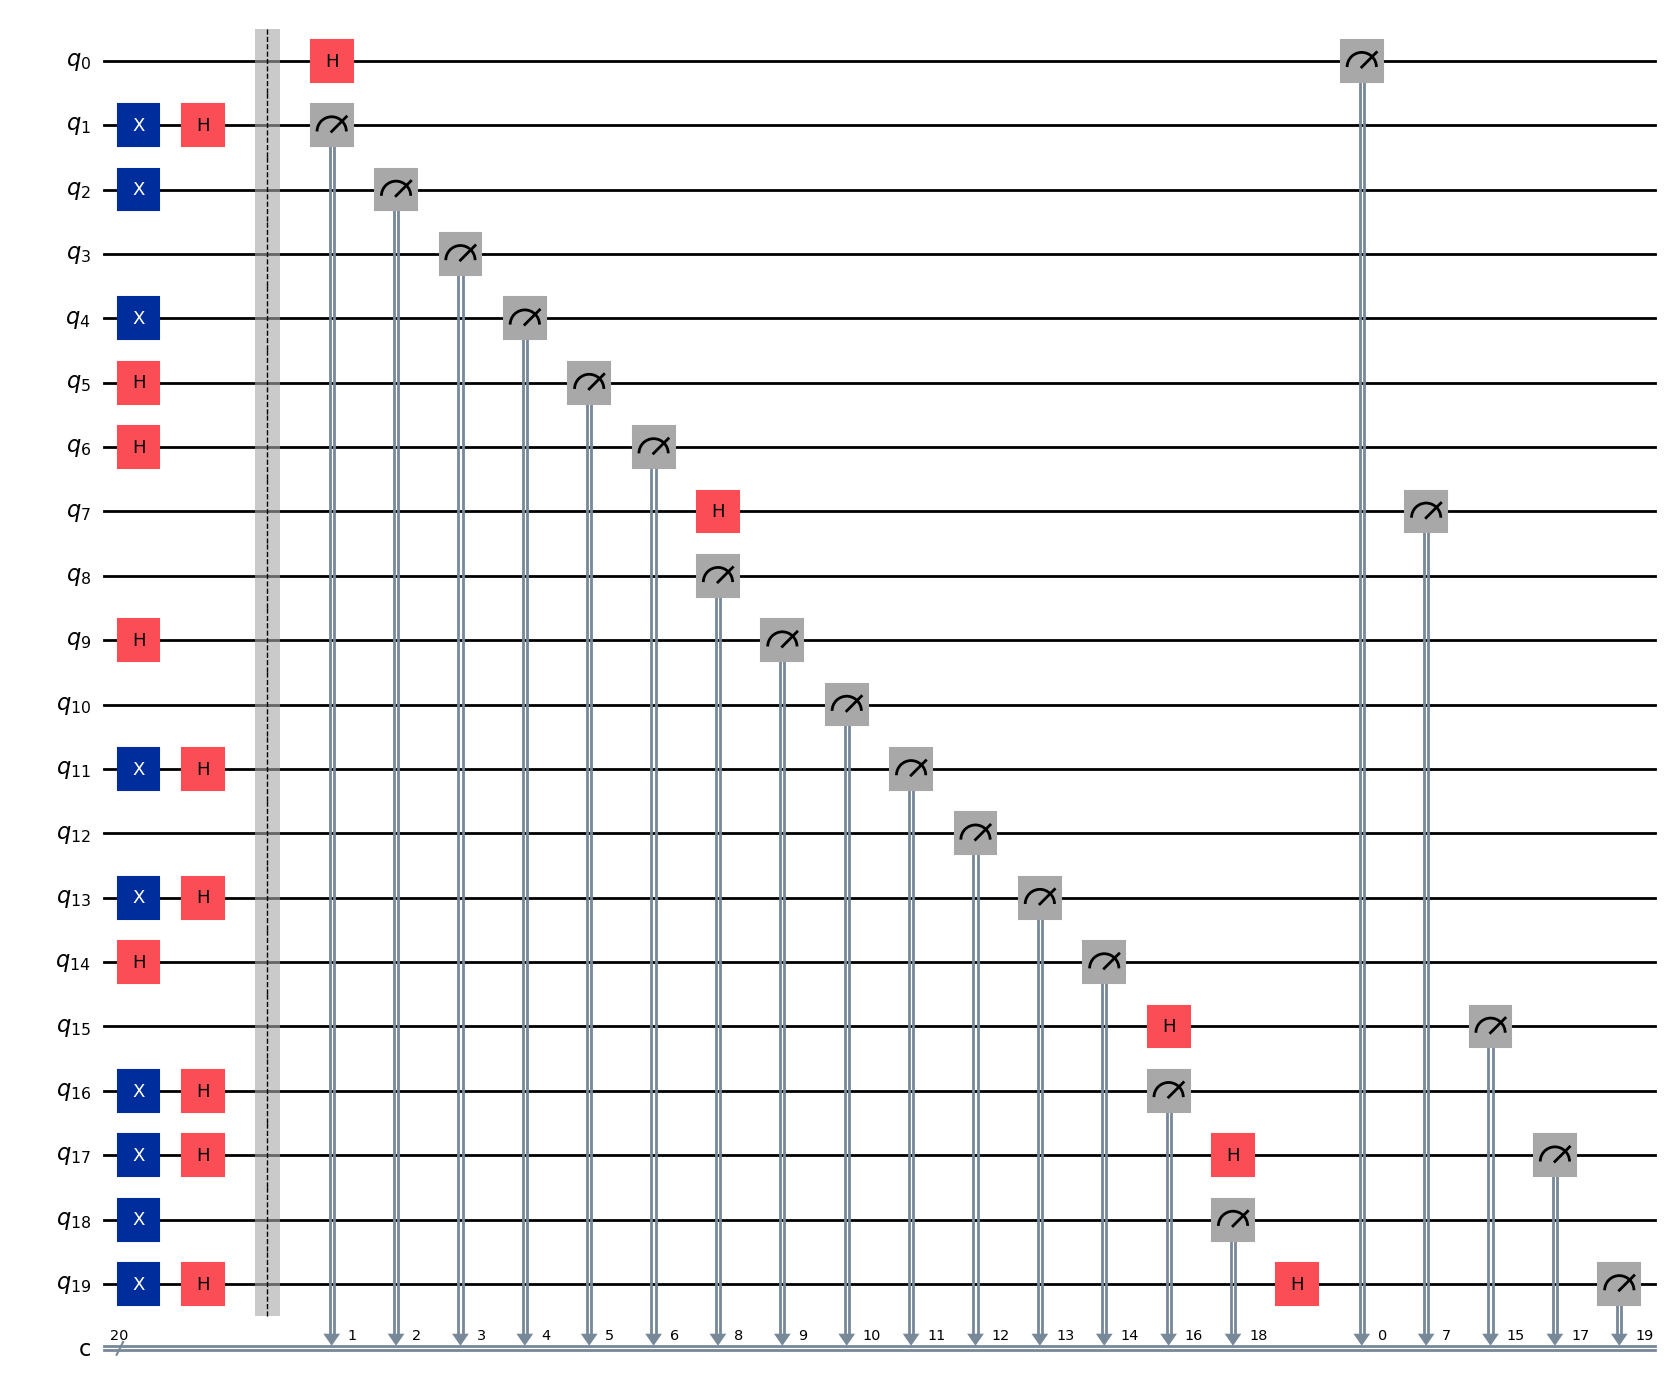

Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Bob's bases are    ['X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X']
Bob's measured bits: [1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 1, 0, 0, 0, 1, 1, 1]
match_count = 9
fidelity    = 1.0
loss        = 0.0
Try  1
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Bob's bases are    ['X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X']
Bob's measured bits: [0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
B

In [8]:
# Entry point
trial_num = 5
fidelities = []
losses = []
record = []

for trial in range(trial_num):
    print("Try ", trial)
    record.append(simulate_bb84(trial, losses, fidelities, backend=sim_backend))
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))

if SAVE_DATA:
    with open("experiment2_1.pkl", "wb") as fid:
        pickle.dump(record, fid)

#### Discussion: 
In each run, Alice and Bob select the same basis in 9 out of 20 instances. Their sifted keys match exactly, as expected in an ideal setting without noise or eavesdropping. As a result, the sifted key is approximately half the length of Alice’s original random bit string, consistent with theoretical expectations. Therefore, the average QBER (qubit error rate), which is the average loss, is 0%.

### 2.2 Experiment: Local Simulation with Depolarizing Noise (without Eve)

As in Subsection 2.1, we run the BB84 QKD protocol five times while keeping Alice’s random bit string, her basis choices, and Bob’s basis choices fixed. In this experiment, however, we introduce a depolarizing noise model (inspired by Assignment 11) that adds errors to single-qubit gates. This noise impacts both Alice’s state preparation and Bob’s measurement operations. We continue to assume that no eavesdropping occurs.

In [9]:
# Inspired by assignment 11 example and https://quantum.cloud.ibm.com/docs/en/guides/build-noise-models#noise-example-1-basic-bit-flip-error-noise-model
noise_model = NoiseModel()
error = depolarizing_error(0.05, 1)
error2 = error.tensor(error)
p_msmt_error = 0.03
error_meas = pauli_error([("X", p_msmt_error), ("I", 1 - p_msmt_error)])
noise_model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3", "h", "x", "z"])
noise_model.add_all_qubit_quantum_error(error2, ["cx"])
noise_model.add_all_qubit_quantum_error(error_meas, "measure")
noisy_sim_backend = AerSimulator(
    noise_model=noise_model,
    method="statevector"
)

In [10]:
noisy_backends_sim = {}
p_depolarizing_array = np.array([1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5])
p_msmt_array = np.array([1e-3, 1e-2, 0.1, 0.3, 0.5])

for p_depolarizing in p_depolarizing_array:
    noisy_backends_sim[p_depolarizing] = {}
    for p_msmt in p_msmt_array:
        model = NoiseModel()
        error = depolarizing_error(p_depolarizing, 1)
        error2 = error.tensor(error)
        error_meas = pauli_error([("X", p_msmt), ("I", 1 - p_msmt)])
        model.add_all_qubit_quantum_error(error, ["u1", "u2", "u3", "h", "x", "z"])
        model.add_all_qubit_quantum_error(error2, ["cx"])
        model.add_all_qubit_quantum_error(error_meas, "measure")
        noisy_backends_sim[p_depolarizing][p_msmt] = AerSimulator(
            noise_model=model,
            method="statevector"
        )

In [12]:
if SWEEP_ERROR_RATES:
    trial_num = 25
    sim_sweep_results = {}
    for p_depolarizing, msmt_dict in noisy_backends_sim.items():
        #print(f"Depolarizing rate: {p_depolarizing}")
        sim_sweep_results[p_depolarizing] = {}
        for p_msmt, backend_inst in msmt_dict.items():
            #print(f"Measurement error rate: {p_msmt}")
            fidelities = []
            losses = []
            sim_sweep_results[p_depolarizing][p_msmt] = []
            for trial in range(trial_num):
                #print(".", end="")
                sim_sweep_results[p_depolarizing][p_msmt].append(simulate_bb84(trial, losses, fidelities, backend=backend_inst, quiet = True))
            #print("")
    if SAVE_DATA:
        with open("experiment2_2_sweep.pkl", "wb") as fid:
            pickle.dump(sim_sweep_results, fid)
    print("\nSweep complete")
else:
    print("Not sweeping over error rates (warning: the sweep takes a long time to run)")
    sim_sweep_results = None
    if os.path.exists("./experiment2_2_sweep.pkl"):
        with open("./experiment2_2_sweep.pkl", "rb") as fid:
            sim_sweep_results = pickle.load(fid)


Sweep complete


In [13]:
def make_loss_plot(data, coldata = p_msmt_array, indexdata = p_depolarizing_array, figname = "exp22meanloss"):
    pd.DataFrame(
        columns=pd.Index(p_msmt_array, name=r"$p_{meas}$"),
        index=pd.Index(p_depolarizing_array, name="$p_{dep}$"),
        data=np.array(data)*100
    ).plot(marker=".", logx=True, ylabel="Loss (%)", title="Mean Loss (Noisy Sim)")
    plt.axhline(11, color=[0.7]*3, linestyle="--")
    plt.savefig(f"./report/paper_journal_style/Figures/{figname}.png")


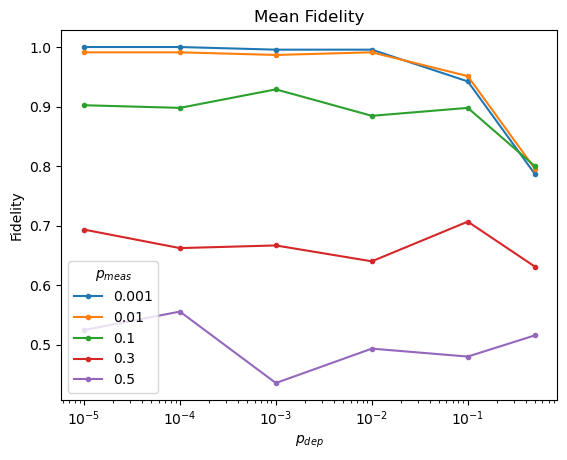

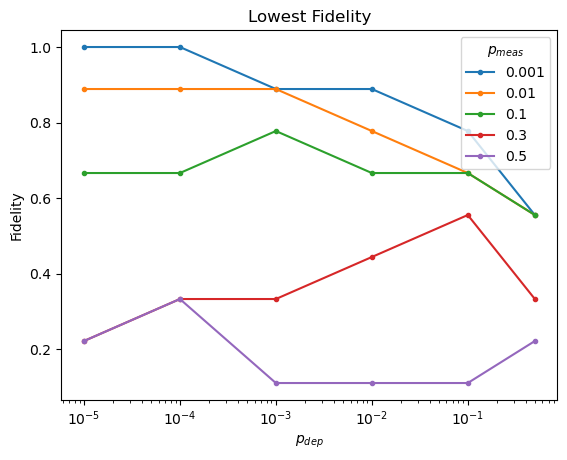

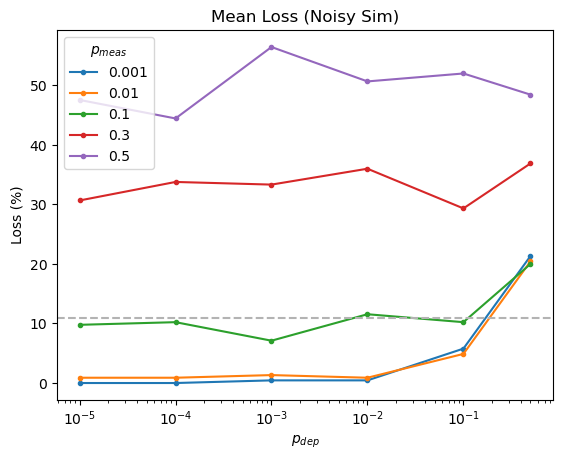

In [14]:
if sim_sweep_results is not None:
    pdepmat, pmsmtmat = np.meshgrid(p_depolarizing_array, p_msmt_array)
    fidelities_grid = np.zeros((len(p_depolarizing_array), len(p_msmt_array)))
    min_fidelities_grid = np.zeros_like(fidelities_grid)
    max_fidelities_grid = np.zeros_like(fidelities_grid)
    loss_grid = np.zeros_like(fidelities_grid)
    max_loss_grid = np.zeros_like(fidelities_grid)
    for pdepidx, pdef in enumerate(p_depolarizing_array):
        for pmidx, pm in enumerate(p_msmt_array):
            fidlist = [vv["stats"]["fidelity"] for vv in sim_sweep_results[pdef][pm]]
            fidelities_grid[pdepidx, pmidx] = np.mean(fidlist)
            min_fidelities_grid[pdepidx, pmidx] = np.min(fidlist)
            max_fidelities_grid[pdepidx, pmidx] = np.max(fidlist)
            losslist = [vv["stats"]["loss"] for vv in sim_sweep_results[pdef][pm]]
            loss_grid[pdepidx, pmidx] = np.mean(losslist)
            max_loss_grid[pdepidx, pmidx] = np.min(losslist)

    df = pd.DataFrame(columns=pd.Index(p_msmt_array, name=r"$p_{meas}$"), index=pd.Index(p_depolarizing_array, name="$p_{dep}$"), data=fidelities_grid)

    df.plot(marker=".", logx=True, ylabel="Fidelity", title="Mean Fidelity")

    pd.DataFrame(
        columns=pd.Index(p_msmt_array, name=r"$p_{meas}$"),
        index=pd.Index(p_depolarizing_array, name="$p_{dep}$"),
        data=min_fidelities_grid
    ).plot(marker=".", logx=True, ylabel="Fidelity", title="Lowest Fidelity")
    plt.show()
    make_loss_plot(loss_grid)

Try  0


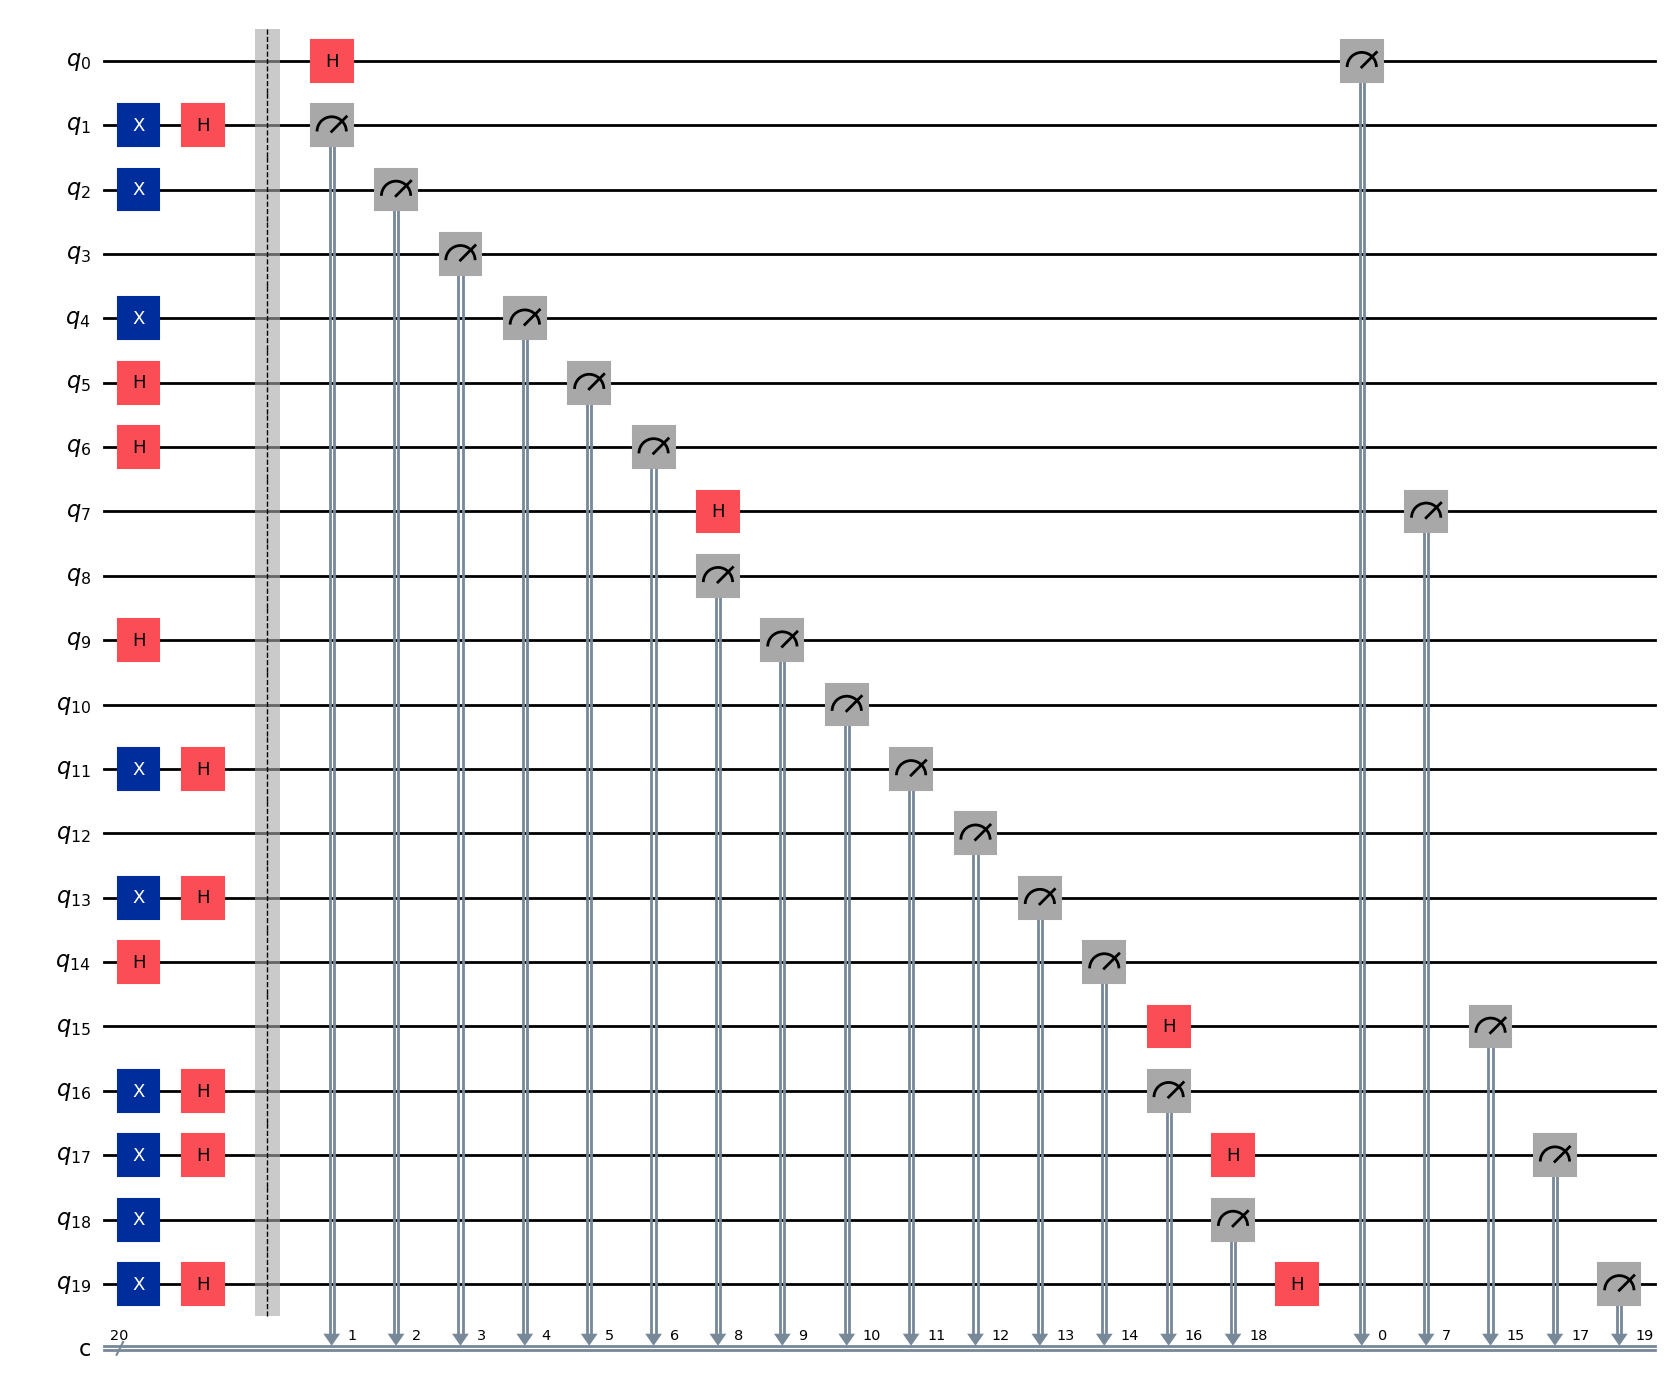

Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Bob's bases are    ['X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X']
Bob's measured bits: [1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 1, 0, 0, 0, 1, 1, 1]
match_count = 9
fidelity    = 1.0
loss        = 0.0
Try  1
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Bob's bases are    ['X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X']
Bob's measured bits: [1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
B

In [15]:
# Entry point
trial_num = 5
fidelities = []
losses = []
record = []

for trial in range(trial_num):
    print("Try ", trial)
    record.append(simulate_bb84(trial, losses, fidelities, backend=noisy_sim_backend))
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))

if SAVE_DATA:
    with open("experiment2_2.pkl", "wb") as fid:
        pickle.dump(record, fid)

#### Discussion

We notice that Alice and Bob's sifted keys are generally no longer identical. In the last run, QBER = 22%; the average QBER over five runs is almost 4.4%. As the measurement and depolarization error rates decrease, Alice and Bob are able to reduce their mean overall QBER. The measurement error rate appears to dominate the QBER trends; better than 10% appears to be the threshold for achieving a sufficient fidelity that QKD is possible. Any lower measurement error rate is robust to a depolarization error rate up to 10% as well.

### 2.3 Experiment: Simulation of BB84 on IBM Platform (without Eve)
In this section, we perform 10 simulations of the BB84 protocol on IBM hardware, assuming no eavesdropping is present.

Try  0


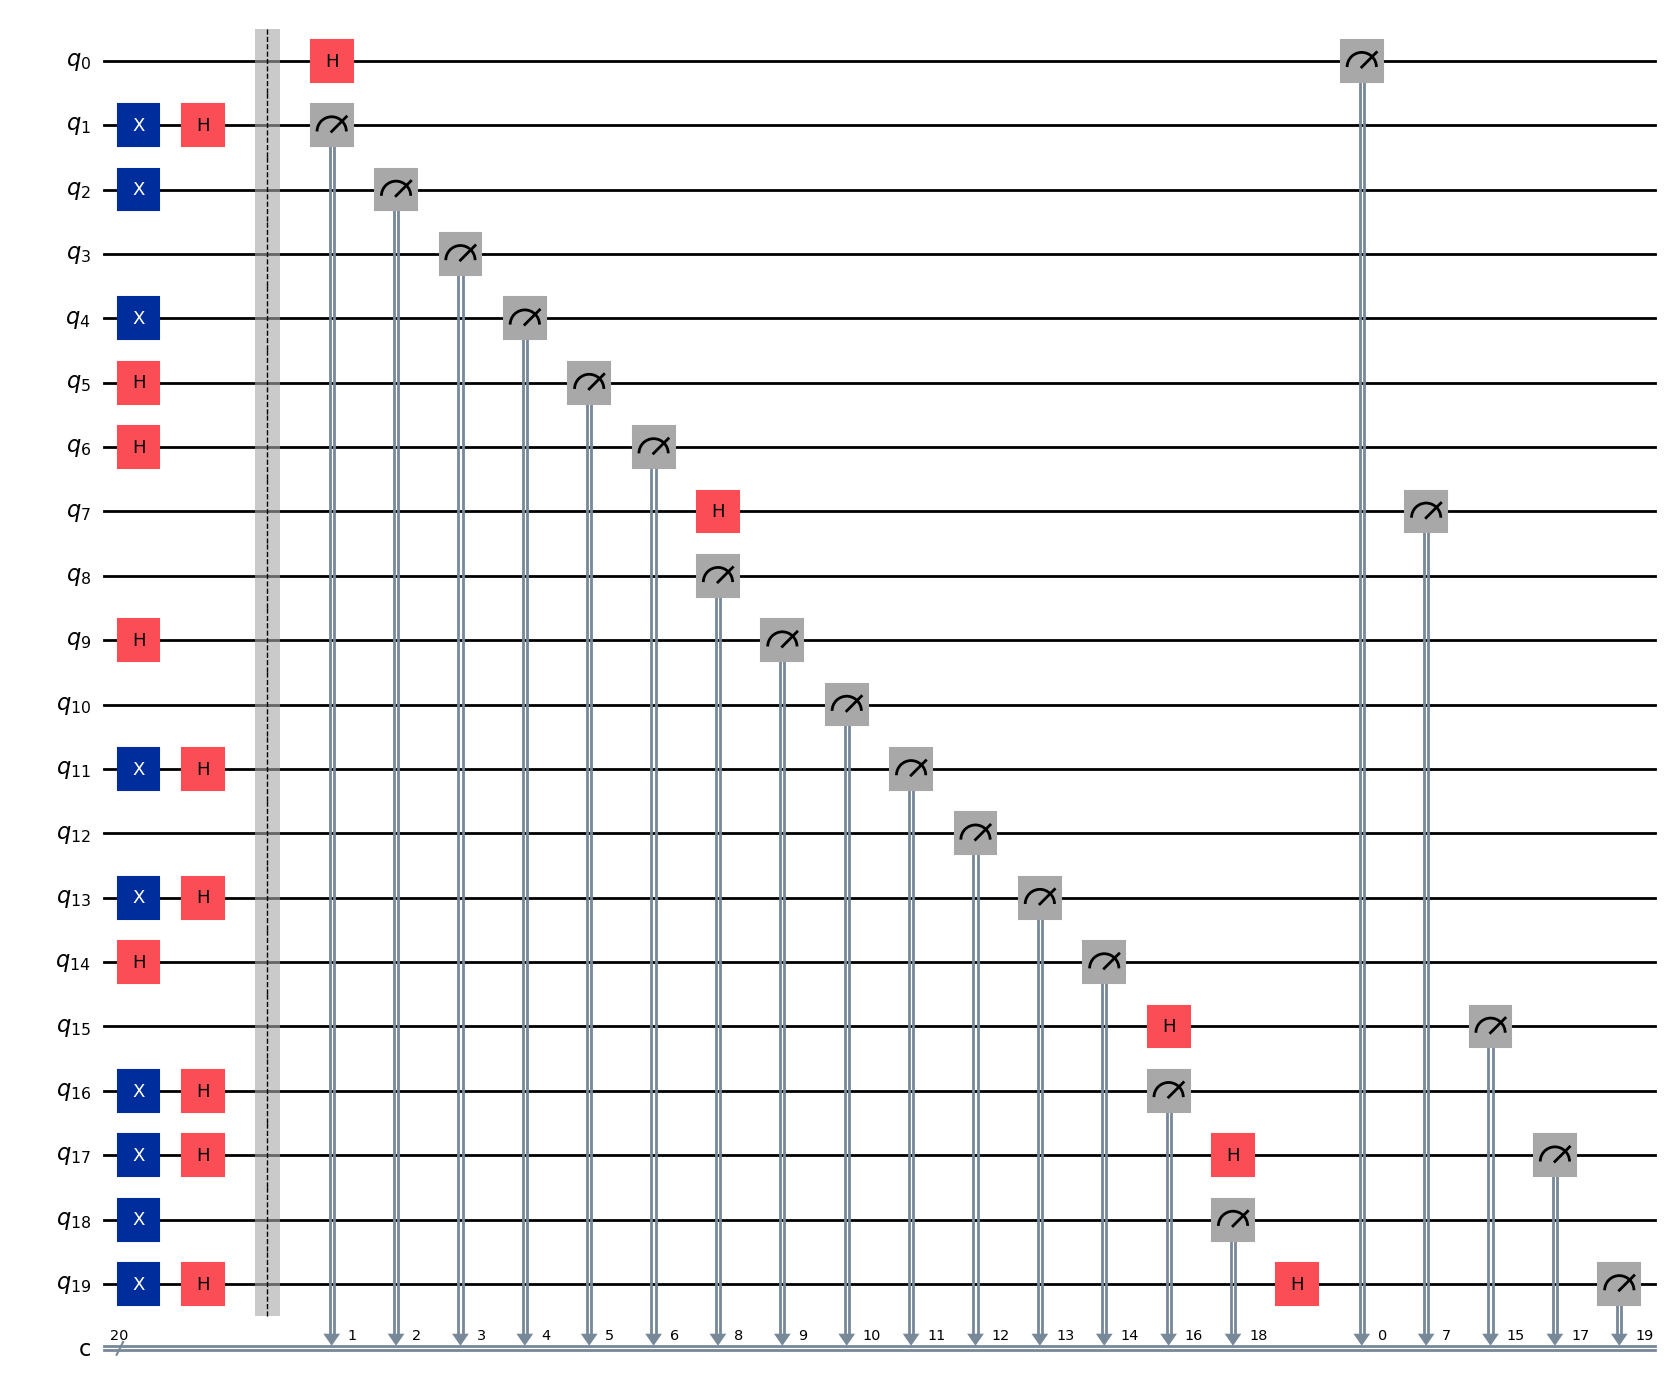

Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Bob's bases are    ['X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X']
Bob's measured bits: [0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 1, 0, 0, 0, 1, 1, 1]
match_count = 9
fidelity    = 1.0
loss        = 0.0
Try  1
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Bob's bases are    ['X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X']
Bob's measured bits: [0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1]
Alice sifted key: [1, 0, 1, 0, 0, 0, 1, 1, 1]
B

In [16]:
# Entry point
if USE_REAL_HARDWARE:
    trial_num = 10
    fidelities = []
    losses = []
    record = []
    
    for trial in range(trial_num):
        print("Try ", trial)
        record.append(simulate_bb84(trial, losses, fidelities, backend=hw_backend))
        
    print("Average fidelity =", sum(fidelities) / len(fidelities))
    print("Average loss     =", sum(losses) / len(losses))
    
    if SAVE_DATA:
        with open("experiment2.pkl", "wb") as fid:
            pickle.dump(record, fid)

#### Discussion

We observe that Alice and Bob’s sifted key is approximately half the length of Alice’s original bit string. Moreover, the QBER is 1.1% in all 10 runs, indicating the high fidelity of IBM’s gates even without error correction and fault-tolerant operations in this simulation.

## 3. Experiment: Simulation of BB84 QKD with Eavesdropper 

The results of the above experiment motivate introducing two additional factors: (1) noise in the quantum circuit and (2) Eve’s eavesdropping. In this attack model, we assume that (1) Eve intercepts each qubit sent by Alice, (2) measures it, and (3) forwards the resulting state to Bob. The theory predicts an average QBER of approximately 25%.

We simulate BB84 with Eve's presence in three scenarios: (1) local simulation without noise; (2) local simulation with noise; (3) simulation on IBM hardware.

In [17]:
def eavesdropper_experiment(num_try, losses, fidelities, backend=hw_backend, bit_num: int = 20, seed: int = 123, sampler = None, quiet=False):
    # Setup
    rng = get_rn_generator(seed)
    if sampler is None:
        if service is not None:
            sampler = Sampler(mode=backend)
        else:
            sampler = StatevectorSampler()

    # Alice selects random bits and bases
    abits = sample_bits(bit_num, rng)
    abase = sample_bits(bit_num, rng)
    
    # Part 1: Alice -> Eve
    qc_eve = QuantumCircuit(bit_num, bit_num)
    
    # Alice prepares qubits
    encode_bb84_states(qc_eve, abits, abase)
    qc_eve.barrier()
    
    # Eve measures in her chosen bases
    ebase = sample_bits(bit_num, rng)
    measure_bb84(qc_eve, ebase)

    # Transpile for the backend
    pm = generate_preset_pass_manager(
        target=backend.target,
        optimization_level=3
    )
    qc_eve_isa = pm.run(qc_eve)
    
    # Execute Eve's interception on hardware
    job_eve = sampler.run([qc_eve_isa], shots=1)
    if not quiet:
        print("Eve Job ID:", job_eve.job_id())
    result_eve = job_eve.result()
    counts_eve, countsint_eve = extract_counts(result_eve)
    # Post-processing
    ebits = counts_to_bbits(counts_eve, bit_num)
    if not quiet:
        print("Eve's bits:\n", ebits)
    
    
    # Part 2: Eve -> Bob
    # Eve construct guess states to send on to Bob
    qc_bob = QuantumCircuit(bit_num, bit_num)
    # Eve encodes using her measured bits in her chosen bases
    encode_bb84_states(qc_bob, ebits, ebase)
    qc_bob.barrier()
    
    # Bob measures in his chosen bases
    bbase = sample_bits(bit_num, rng)
    measure_bb84(qc_bob, bbase)
    
    # Transpile for the backend
    qc_bob_isa = pm.run(qc_bob)
    # Execute Bob's measurement on hardware
    job_bob = sampler.run([qc_bob_isa], shots=1)
    if not quiet:
        print("Bob Job ID:", job_bob.job_id())
    result_bob = job_bob.result()
    # Post-process Bob's measurement
    counts_bob, countsint_bob = extract_counts(result_bob)
    bbits = counts_to_bbits(counts_bob, bit_num)
    
    # Compare Alice's and Bob's bits
    agoodbits, bgoodbits = sift_key(abits, abase, bbase, bbits)
    stats = key_statistics(agoodbits, bgoodbits)
    if not quiet:
        print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats, ebits, ebase)
    
    if stats["sifted_length"] > 0:
        fidelities.append(stats["fidelity"])
        losses.append(stats["loss"])
    return {"abits": abits, "abase": abase, "bbits": bbits, "bbase": bbase, "ebits": ebits, "ebase": ebase, "bob_result": result_bob, "eve_result": result_eve, "agoodbits": agoodbits, "bgoodbits": bgoodbits, "stats": stats}

#### 3.1 Experiment: Local Simulation of BB84 with Eavesdropping but without Noise

In [18]:
# Entry point
trial_num = 5
fidelities = []
losses = []
record = []

for trial in range(trial_num):
    print("Try ", trial)
    record.append(eavesdropper_experiment(trial, losses, fidelities, backend=sim_backend))
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))

if SAVE_DATA:
    with open("experiment3_1.pkl", "wb") as fid:
        pickle.dump(record, fid)

Try  0
Eve Job ID: 5092d0da-9c7e-44a1-99ec-38ffd5705e50
Eve's bits:
 [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Bob Job ID: 8101a951-a684-476e-a941-ec764273e568
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Eve base:    [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1]
Eve bits:    [1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Bob's bases are    ['X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X']
Bob's measured bits: [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1]
Alice sifted key: [1, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [0, 1, 0, 1, 0, 1, 0, 1]
match_count = 5
fidelity    = 0.625
loss        = 0.375
Try  1
Eve Job ID: 19cb7ac1-02e5-4363-a117-8e4ccc634e36
Eve's bits:
 [1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1]
Bob Job ID: 6d7ad9e

#### Discussion

When Eve is present in the quantum channel, the average QBER increases to 25%, assuming there is no noise in the quantum system comprising Alice's preparation device, Bob's measurement device, and the quantum channel between Alice and Bob. We note that this empirical result support the theoretical prediction of 25% QBER when eavesdropping is present.

#### 3.2 Experiment: Local Simulation of BB84 with Eavesdropping and Noise

In [19]:
# Entry point
trial_num = 5
fidelities = []
losses = []
record = []

for trial in range(trial_num):
    print("Try ", trial)
    record.append(eavesdropper_experiment(trial, losses, fidelities, backend=noisy_sim_backend))
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))

if SAVE_DATA:
    with open("experiment3_2.pkl", "wb") as fid:
        pickle.dump(record, fid)

Try  0
Eve Job ID: 83037ee6-5c00-46d5-81c6-d04d50ce6b7c
Eve's bits:
 [1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1]
Bob Job ID: 1eda3896-ad71-4e8b-aba1-606dd2b05968
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Eve base:    [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1]
Eve bits:    [1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1]
Bob's bases are    ['X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X']
Bob's measured bits: [1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1]
Alice sifted key: [1, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 0, 0, 0, 0, 1, 1, 1]
match_count = 7
fidelity    = 0.875
loss        = 0.125
Try  1
Eve Job ID: e9746715-0441-4d91-bd14-b26d1d621956
Eve's bits:
 [1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1]
Bob Job ID: 6bd9bec

#### Discussion

Under the assumption of eavesdropping and noisy channel (with the noise model in Section 2), the average QBER increases further to 25% for five runs. This observation is consistent with the average QBER of 25% when the channel is perfect.

In [20]:
if SWEEP_ERROR_RATES:
    trial_num = 25
    sim_sweep_results = {}
    for p_depolarizing, msmt_dict in noisy_backends_sim.items():
        #print(f"Depolarizing rate: {p_depolarizing}")
        sim_sweep_results[p_depolarizing] = {}
        for p_msmt, backend_inst in msmt_dict.items():
            #print(f"Measurement error rate: {p_msmt}")
            fidelities = []
            losses = []
            sim_sweep_results[p_depolarizing][p_msmt] = []
            for trial in range(trial_num):
                #print(".", end="")
                sim_sweep_results[p_depolarizing][p_msmt].append(eavesdropper_experiment(trial, losses, fidelities, backend=backend_inst, quiet = True))
            #print("")
    if SAVE_DATA:
        with open("experiment3_2_sweep.pkl", "wb") as fid:
            pickle.dump(sim_sweep_results, fid)
    print("\nSweep complete")
else:
    print("Not sweeping over error rates (warning: the sweep takes a long time to run")
    sim_sweep_results = None
    if os.path.exists("./experiment_3_2_sweep.pkl"):
        with open("./experiment_3_2_sweep.pkl", "rb") as fid:
            sim_sweep_results = pickle.load(fid)


Sweep complete


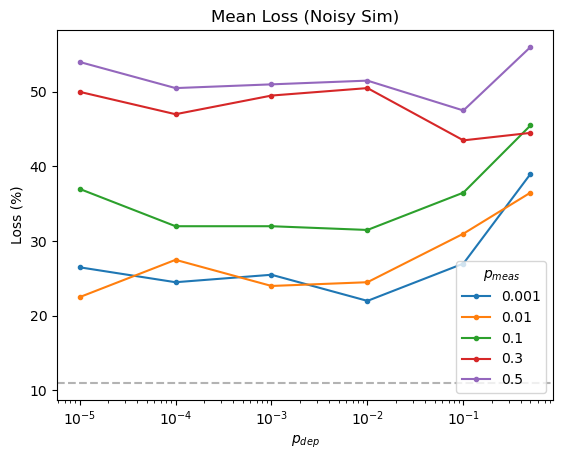

In [21]:
if sim_sweep_results is not None:
    loss_grid = np.zeros((len(p_depolarizing_array), len(p_msmt_array)))
    for pdepidx, pdef in enumerate(p_depolarizing_array):
        for pmidx, pm in enumerate(p_msmt_array):
            try:
                losslist = [vv["stats"]["loss"] for vv in sim_sweep_results[pdef][pm]]
                loss_grid[pdepidx, pmidx] = np.mean(losslist)
            except:
                print(pdepidx, pmidx)
                print(pm)
                print(losslist)
                raise
    make_loss_plot(loss_grid, figname="exp32meanloss")

#### 3.3 Experiment: Simulation of BB84 with Eavesdropping on IBM Hardware (with Noise)

In [22]:
# Entry point
if USE_REAL_HARDWARE:
    trial_num = 5
    fidelities = []
    losses = []
    record = []
    
    for trial in range(trial_num):
        print("Try ", trial)
        record.append(eavesdropper_experiment(trial, losses, fidelities, backend=hw_backend))
        
    print("Average fidelity =", sum(fidelities) / len(fidelities))
    print("Average loss     =", sum(losses) / len(losses))
    
    if SAVE_DATA:
        with open("experiment3_hw_backend.pkl", "wb") as fid:
            pickle.dump(record, fid)

Try  0
Eve Job ID: d7r46ciudops73959if0
Eve's bits:
 [1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1]
Bob Job ID: d7r46e7ljm6s73b9u1ng
Alice's bits are  [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'Z', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'Z', 'X']
Eve base:    [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1]
Eve bits:    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1]
Bob's bases are    ['X', 'X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X']
Bob's measured bits: [1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1]
Alice sifted key: [1, 1, 0, 0, 0, 1, 1, 1]
Bob sifted key:   [1, 1, 0, 0, 0, 0, 0, 1]
match_count = 6
fidelity    = 0.75
loss        = 0.25
Try  1
Eve Job ID: d7r46g2udops73959iig
Eve's bits:
 [1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1]
Bob Job ID: d7r46hkf3ras73b6gitg
Alice's bits are  [0, 1, 1, 0, 1, 0,

#### Discussion

This simulation runs on IBM hardware, which is noisy, with Eve's presence. The average QBER for five runs is approximately to 28%.

## 4. Experiment: Error correction

In this experiment, we will demonstrate how a classical error-correcting method can correct Bob's bits that differ from Alice's corresponding bits in their sifted keys. We implement a Cascade error-correction protocol, which is a simple (but ineffecient) method for correcting errors based on the comparison of the parity check of Alice and Bob's bits. 

However, to come up with Alice and Bob's sifted keys that are meaningful for error correction, we need to generate these sifted keys using the above local simulation of BB84 with noise but without Eve's presence so that the QBER stays below the 11% threshold. Otherwise, the BB84 protocol would be aborted before error correction could be carried out.

In addition, Alice's and Bob's sifted keys need to be long enough for encryption of a text message. Since we will encrypt the plaintext "BB84", the sifted keys must be sufficiently long after going through error correction and privacy amplification. In this section, we will run our local simulation of BB84 with noise, but without Eve's presence, five times with 24 qubits at a time. Then, we will concatenate the sifted keys obtained from individual runs to form a pair of longer sifted keys. This approach is required due to the limitation on the number of qubits that can be prepared in Qiskit.


#### 4.1 Generation of Long Sifted Keys

In [23]:
def noise_local_simulate_bb84(num_try, losses, fidelities, backend=sim_backend, bit_num: int = 24, seed = None, sampler = None):
    # Setup
    rng = get_rn_generator(seed)
    if sampler is None:
        if service is not None:
            sampler = Sampler(mode=backend)
        else:
            sampler = StatevectorSampler()

    # Alice selects random bits and bases
    abits = sample_bits(bit_num, rng)
    abase = sample_bits(bit_num, rng)
    
    # 128 qubits, 128 classical bits for measurement results
    qc = QuantumCircuit(bit_num, bit_num)
    
    # Encoding: Alice prepares qubits
    encode_bb84_states(qc, abits, abase)
    qc.barrier()
    
    # Bob measures in his chosen bases
    bbase = sample_bits(bit_num, rng)
    measure_bb84(qc, bbase)

    # if num_try == 0:
    #     display(qc.draw("mpl"))
    
    # Transpile for the backend
    pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
    qc_isa = pm.run(qc)

    # Execute the job
    job = backend.run(qc_isa, shots=1)

    result = job.result()
    
    # Post-process
    # counts, countsint = extract_counts(result)
    counts = result.get_counts()
    bbits = counts_to_bbits(counts, bit_num)
    
    agoodbits, bgoodbits = sift_key(abits, abase, bbase, bbits)
    stats = key_statistics(agoodbits, bgoodbits)
    
    print_protocol_summary(abits, abase, bbase, bbits, agoodbits, bgoodbits, stats)

    if stats["sifted_length"] > 0:
        fidelities.append(stats["fidelity"])
        losses.append(stats["loss"])
    return {"result": result, "abits": abits, "abase": abase, "bbits": bbits, "bbase": bbase, "agoodbits": agoodbits, "bgoodbits": bgoodbits, "stats": stats}

In [24]:
# Entry point
trial_num = 5
fidelities = []
losses = []
record = []
alice_sifted_all = []
bob_sifted_all = []

for trial in range(trial_num):
    print("Try ", trial)
    trial_record = noise_local_simulate_bb84(trial, losses, fidelities, backend=noisy_sim_backend)
    record.append(trial_record)
    
    # Save data
    alice_sifted_all.extend(trial_record["agoodbits"])
    bob_sifted_all.extend(trial_record["bgoodbits"])
    
print("Average fidelity =", sum(fidelities) / len(fidelities))
print("Average loss     =", sum(losses) / len(losses))

if SAVE_DATA:
    with open("data_for_error_correction.pkl", "wb") as fid:
        pickle.dump(record, fid)
        
    with open("sifted_keys.pkl", "wb") as fid:
        pickle.dump({
            "alice_sifted_key": alice_sifted_all,
            "bob_sifted_key": bob_sifted_all,
            "trial_num": trial_num
        }, fid)

print("Alice's whole sifted key: ", alice_sifted_all)
print("Bob's whole sifted key: ", bob_sifted_all)

Try  0
Alice's bits are  [1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0]
Alice's bases are  ['Z', 'X', 'X', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'X']
Bob's bases are    ['Z', 'Z', 'Z', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'X', 'X', 'Z', 'X']
Bob's measured bits: [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0]
Alice sifted key: [1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0]
Bob sifted key:   [1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0]
match_count = 15
fidelity    = 0.9375
loss        = 0.0625
Try  1
Alice's bits are  [0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1]
Alice's bases are  ['Z', 'X', 'Z', 'X', 'Z', 'Z', 'X', 'Z', 'X', 'X', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'X', 'X', 'X', 'Z', 'Z', 'X', 'X', 'X']
Bob's bases are    ['X', 'X', 'X', 'Z', 'Z', 'Z', 'X', 'Z', 'Z', 'Z', 'Z', 'X', 'X', 'X', 'X', 'X

#### Discussion

We generated a pair of sifted keys with sufficiently low QBER (~ 7.7%), i.e., below the threshold of 11%, which is required for error correction. The sifted keys are not identical. In fact, one can inspect the last 10 bits and notice the differences between the two sifted keys. 

#### 4.2 Error Correcting Bob's Sifted Key via Cascade Protocol

In [25]:
def bit_error_rate(
    input_bits: NDArray[np.int64], output_bits: NDArray[np.int64]
) -> NDArray[np.int64]:
    """
    Computes the quantum bit error rate between two sets of bits
    """

    if np.size(input_bits) != np.size(output_bits):
        raise ValueError("input_bits and output_bits must be of the same size")
    if isinstance(input_bits, list):
        input_bits = np.array(input_bits)
    if isinstance(output_bits, list):
        output_bits = np.array(output_bits)

    if np.size(input_bits) == 0:
        return np.nan
    else:
        return np.sum(input_bits.flatten() != output_bits.flatten()) / np.size(
            input_bits
        )

        
def compute_parity(bits):
    """
    Returns 0 if number of 1s is even, 1 if odd.
    This is the key operation used to detect mismatches.
    """
    return sum(bits) % 2


def locate_and_fix_error(alice_key, bob_key, indices):
    """
    This function uses binary search recursively to locate a single 
    incorrect bit using parity checks.

    Idea:
    - Split the block into two halves
    - Compare parity of left half
    - If mismatch → error is in left half
    - Else → error is in right half
    - Continue until one bit remains
    """

    # Base case: only one bit → must be the error
    if len(indices) == 1:
        i = indices[0]
        bob_key[i] ^= 1  # Flip Bob's bit to match Alice
        return i

    # Split into two halves
    mid = len(indices) // 2
    left_half = indices[:mid]
    right_half = indices[mid:]

    # Compute parities for left half
    alice_parity = compute_parity([alice_key[i] for i in left_half])
    bob_parity = compute_parity([bob_key[i] for i in left_half])

    # Decide which half contains the error
    if alice_parity != bob_parity:
        return locate_and_fix_error(alice_key, bob_key, left_half)
    else:
        return locate_and_fix_error(alice_key, bob_key, right_half)


def cascade_protocol(alice_key, bob_key, num_passes=4, initial_block_size=2):
    """
    Use the Cascade protocol to correct Bob's erroneous bits in his sifted key

    Parameters:
    - alice_key: correct reference key
    - bob_key: noisy key to fix
    - num_passes: number of iterations
    - initial_block_size: size of blocks in first pass

    """

    n = len(alice_key)
    bob_corrected = bob_key.copy()
    leakage = 0

    # Store block structure from each pass (for backtracking)
    all_pass_blocks = []

    block_size = initial_block_size

    for p in range(num_passes):
        print(f"\nPass {p+1} (block size = {block_size})")

        # Shuffle indices (important for randomness)
        indices = list(range(n))
        random.shuffle(indices)

        # Divide into blocks
        blocks = [
            indices[i:i + block_size]
            for i in range(0, n, block_size)
        ]

        # Store this pass's blocks for later backtracking
        all_pass_blocks.append(blocks)

        # Check each block
        for block in blocks:
            alice_parity = compute_parity([alice_key[i] for i in block])
            bob_parity = compute_parity([bob_corrected[i] for i in block])

            # If parity mismatch → odd number of errors
            if alice_parity != bob_parity:
                leakage += 1
                error_index = locate_and_fix_error(alice_key, bob_corrected, block)
                print(f"Corrected error at position {error_index}")

                # Backtracking step: Fixing one error might reveal others in previous passes
                for previous_blocks in all_pass_blocks[:-1]:
                    for prev_block in previous_blocks:
                        a_par = compute_parity([alice_key[i] for i in prev_block])
                        b_par = compute_parity([bob_corrected[i] for i in prev_block])

                        if a_par != b_par:
                            locate_and_fix_error(alice_key, bob_corrected, prev_block)

        # Increase block size for next pass
        block_size *= 2

    return bob_corrected, leakage
    

In [26]:
# Run Cascade
qber_estimate = bit_error_rate(input_bits=alice_sifted_all[0:10], output_bits=bob_sifted_all[0:10])

print("Estimated QBER:", qber_estimate)

if qber_estimate > 0.11:
    print("Abort because of posible eavesdropping or too noisy.")
else:
    corrected_bob, leakage = cascade_protocol(alice_sifted_all, bob_sifted_all)
    print("Leakage:", leakage)
    print("\nAfter Cascade Protocol:")
    print("Corrected Bob:", corrected_bob)
    print("Match:", corrected_bob == alice_sifted_all)

Estimated QBER: 0.1

Pass 1 (block size = 2)
Corrected error at position 19
Corrected error at position 6
Corrected error at position 47
Corrected error at position 37

Pass 2 (block size = 4)

Pass 3 (block size = 8)

Pass 4 (block size = 16)
Leakage: 4

After Cascade Protocol:
Corrected Bob: [1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1]
Match: True


#### Discussion

The Cascade protocol begins by checking the QBER rate based on a few bits selected from Alice and Bob's sifted keys. In reality, this means that Bob gives up a small number of his (supposedly secret) bits by sending them to Alice to compute an estimated QBER. Here, we decided to select the first 10 bits for simplicity. If this value is less than 11%, error correction is performed on the sifted keys by the Cascade protocol. Otherwise, Alice and Bob will abort the BB84 QKD protocol.

The output shows how the Cascade protocol recursively locates and fixes the mismatched bits based on the block size. Cascade makes multiple passes with different block sizes in a way that errors corrected on the $i^{th}$ pass can reveal the location of more errors under permutations of the key in another pass $i'$ where $i\ne i'$. In this case, the protocol found five mismatches, which are called leakage because the non-zero parity check bits may reveal additional information to Eve in the classical channel. The Cascade protocol we implemented works in one direction. That is, the protocol corrects Bob's erroneous bits so that his final key matches Alice's sifted key. We checked that Bob's corrected key is now identical to Alice's sifted key.  

## 5. Experiment: Privacy Amplification

After Bob's sifted key has been corrected to match Alice's sifted key, the final step of QKD is privacy amplification, which is designed to minimze the leakage information that may occur during error correction due to Eve's eavesdropping on the classical channel. We use the typical Toeplitz Hash method for this step due to its simplicity. The hash of a binary vector is just the multiplication modulo 2 of a binary Toeplitz matrix with this vector. Of course, there are stronger hash functions. Nonetheless, the Toeplitz Hash is adequate for this problem. 

Using a random binary Toeplitz matrix, hashing compresses an original vector into a shorter vector whose entries are linear combinations of the entries in the original vector. In doing so, the bits in Alice's sifted key or Bob's corrected key are now correlated, which makes it more difficult for Eve to learn. Hashing is performed individually by both and Alice and Bob. Hence, they had to agree on this hashing scheme beforehand.


In [27]:
def generate_toeplitz(rows, cols):
    """
    Use Toeplitz matrix for hashing
    """
    first_row = [random.randint(0, 1) for _ in range(cols)]
    first_col = [first_row[0]] + [random.randint(0, 1) for _ in range(rows - 1)]

    matrix = []
    for i in range(rows):
        row = []
        for j in range(cols):
            if j >= i:
                row.append(first_row[j - i])
            else:
                row.append(first_col[i - j])
        matrix.append(row)
    return matrix

def matmul_mod2(matrix, vector):
    return [sum(r * v for r, v in zip(row, vector)) % 2 for row in matrix]


In [28]:
if qber_estimate <= 0.11:
    a_key = alice_sifted_all[10:]
    b_key = corrected_bob[10:]
    N = len(a_key)
    SECURITY_MARGIN = 10
    final_len = N - leakage - SECURITY_MARGIN
    
    H = generate_toeplitz(final_len, N)
    final_alice_key = matmul_mod2(H, a_key)
    final_bob_key = matmul_mod2(H, b_key)
    
    print("Alice's final key:", final_alice_key)
    print("Bob's final key:", final_bob_key)
else:
    print("Abort because of posible eavesdropping or too noisy.")

Alice's final key: [1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]
Bob's final key: [1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]


#### Discussion

Using the leakage information and the number of bits given up by Bob to compute the estimated QBER during error correction, we arrive at a slightly shorter shared key. Since we used the first 10 bits of Alice's and Bob's sifted key to estimate QBER, we first remove these 10 bits from the shared key. Also, the leakage was found to be 5. Thus, the length of the final shared key is $N - 15$, where $N$ is the length of the sifted keys. 

A random binary Toeplitz matrix of size $(N-15) \times N$ was generated. The above output shows Alice's and Bob's final key, which is long enough for Alice to encrypt "BB84". 

## 6. Experiment: One-time Pad Encryption, Decryption

Using the final key produced by privacy amplification, we show how one-time pad encryption can be performed on the plaintext "BB84", which can be represented as a 32-bit string. This is why we need a sufficient long key, which must be at least 32-bit long in this case. Here, we assume that Alice encrypts "BB84" using her key, and sends the ciphertext (in binary) to Bob through their classical channel. Bob subsequently decrypts the ciphertext with the shared secret key and recovers the plaintext. Before encryption, Alice validates the length of the shared key to ensure that the key is longer than 32 bits. 

In [29]:
def string2bits(s):
    return ''.join(format(b, '08b') for b in s.encode('utf-8'))

def bits2string(b):
    bytes_list = [b[i:i+8] for i in range(0, len(b), 8)]
    return ''.join(chr(int(byte, 2)) for byte in bytes_list)

def xor_bits(data_bits, key_bits):
    # Repeat or trim key to match data length
    key_repeated = (key_bits * ((len(data_bits) // len(key_bits)) + 1))[:len(data_bits)]
    return ''.join('1' if db != kb else '0' for db, kb in zip(data_bits, key_repeated))

def encrypt(plaintext, key_bits):
    data_bits = string2bits(plaintext)
    cipher_bits = xor_bits(data_bits, key_bits)
    return cipher_bits

def decrypt(cipher_bits, key_bits):
    decrypted_bits = xor_bits(cipher_bits, key_bits)
    return bits2string(decrypted_bits)

def validate_key_length(key_bits, data_bits_length):
    """Ensure the key is the correct length for the data to be encrypted or decrypted."""
    
    key_length = len(key_bits)
    if key_length == 0:
        print("Key must not be empty.")
        return 0
    
    if key_length < data_bits_length:
        print("Key bits must be longer than than data bits.")
        return 0
        
    if key_length > data_bits_length:
        key_bits = key_bits[:data_bits_length]
    
    return key_bits

In [31]:
plaintext = "BB84"
print("Alice's Plaintext:", plaintext)

bitstring_message = string2bits(plaintext)
messagelen = len(bitstring_message)

# Alice uses her keys above to encrypt "BB84"
enkey = validate_key_length(final_alice_key, messagelen)
print("Alice's Encryption Key:", enkey)

# Convert key to a string of '0' and '1'
cipher = encrypt(plaintext, ''.join(map(str, enkey)))
print("Ciphertext in bits:", cipher)

dekey = validate_key_length(final_bob_key, messagelen)
# Convert key to a string of '0' and '1'
print("Bob's Decryption Key:", dekey)
decrypted_message = decrypt(cipher, ''.join(map(str, dekey)))
print("Bob's Decrypted Text:", decrypted_message)

Alice's Plaintext: BB84
Alice's Encryption Key: [1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1]
Ciphertext in bits: 11001111101011000101001111011001
Bob's Decryption Key: [1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1]
Bob's Decrypted Text: BB84


#### Discussion

In the output above, Alice's key is obtained by truncating the shared key obtained through privacy amplification. In this case, Alice only uses the first 32 bits of the shared key to implement one-time pad encryption. The output also shows the ciphertext in binary and Bob's decrypted message. Note that we have simplified the process of recovering the plaintext by assuming that Bob knows the plaintext's length (in binary). In practice, it is straightforward for Alice to pad the plaintext with 0's before encryption and for Bob to extract the original message from the decrypted bit string. 